Python basics: 
data structures, functions, and scripting Pandas for data manipulation (reading CSV, filtering, merging) 
Intro to data visualization: Matplotlib & Seaborn

In [201]:
import pandas as pd
# import numpy as np

df = pd.read_csv('data.csv')
print(df.head())
df.info()
df.describe()

   Duration          Date  Pulse  Maxpulse  Calories
0        60  '2020/12/01'    110       130     409.1
1        60  '2020/12/02'    117       145     479.0
2        60  '2020/12/03'    103       135     340.0
3        45  '2020/12/04'    109       175     282.4
4        45  '2020/12/05'    117       148     406.0
<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     str    
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 1.4 KB


,Duration,Pulse,Maxpulse,Calories
count,32.000000,32.000000,32.000000,30.000000
mean,68.437500,103.500000,128.500000,304.680000
std,70.039591,7.832933,12.998759,66.003779
min,30.000000,90.000000,101.000000,195.100000
25%,60.000000,100.000000,120.000000,250.700000
50%,60.000000,102.500000,127.500000,291.200000
75%,60.000000,106.500000,132.250000,343.975000
max,450.000000,130.000000,175.000000,479.000000


Cleaning

In [202]:
# missing values
missing_values = df.isnull().sum()
print(missing_values)

Duration    0
Date        1
Pulse       0
Maxpulse    0
Calories    2
dtype: int64


In [203]:
# Calories (missing values)
df = df.fillna({'Calories': df['Calories'].mean()}, inplace=True)
# print(df['Calories'].isnull().sum()) #0

In [204]:
# duplicates
df = df.drop_duplicates()
print(df.duplicated().sum()) #0

0


In [205]:
# date
df['Date'] = pd.to_datetime(df['Date'], format= 'mixed')
print(df['Date'].dtype) #datetime64[ns]
# print(df['Date'].isnull().sum()) #1
df.dropna(subset=['Date'], inplace=True)

datetime64[us]


In [206]:
'''# outlier
q1 = df['Duration'].quantile(0.25)
q3 = df['Duration'].quantile(0.75)
iqr = q3 - q1
outlier_threshold = 1.5 * iqr
outliers = df[(df['Duration']>(q3 + outlier_threshold))]
print(outliers) #450
index = outliers.index
# df = df.loc[index, 'Duration'].replace(df.loc[index, 'Duration'], df.loc[index, 'Duration']/10)
print(df.loc[outliers.index, 'Duration']) #45
print(outliers)
'''

"# outlier\nq1 = df['Duration'].quantile(0.25)\nq3 = df['Duration'].quantile(0.75)\niqr = q3 - q1\noutlier_threshold = 1.5 * iqr\noutliers = df[(df['Duration']>(q3 + outlier_threshold))]\nprint(outliers) #450\nindex = outliers.index\n# df = df.loc[index, 'Duration'].replace(df.loc[index, 'Duration'], df.loc[index, 'Duration']/10)\nprint(df.loc[outliers.index, 'Duration']) #45\nprint(outliers)\n"

In [ ]:
df.loc[7, 'Duration'] = 45

In [208]:
print(df.head())
print(df.info())
print(df.describe())
df.to_csv('cleaned_data.csv', index=False)

   Duration       Date  Pulse  Maxpulse  Calories
0        60 2020-12-01    110       130     409.1
1        60 2020-12-02    117       145     479.0
2        60 2020-12-03    103       135     340.0
3        45 2020-12-04    109       175     282.4
4        45 2020-12-05    117       148     406.0
<class 'pandas.DataFrame'>
Index: 30 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Duration  30 non-null     int64         
 1   Date      30 non-null     datetime64[us]
 2   Pulse     30 non-null     int64         
 3   Maxpulse  30 non-null     int64         
 4   Calories  30 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(3)
memory usage: 2.5 KB
None
        Duration                 Date       Pulse    Maxpulse    Calories
count  30.000000                   30   30.000000   30.000000   30.000000
mean   56.000000  2020-12-15 19:12:00  103.733333  129.100000  307.235

Visualization

In [209]:
import matplotlib.pyplot as plt
import seaborn as sns

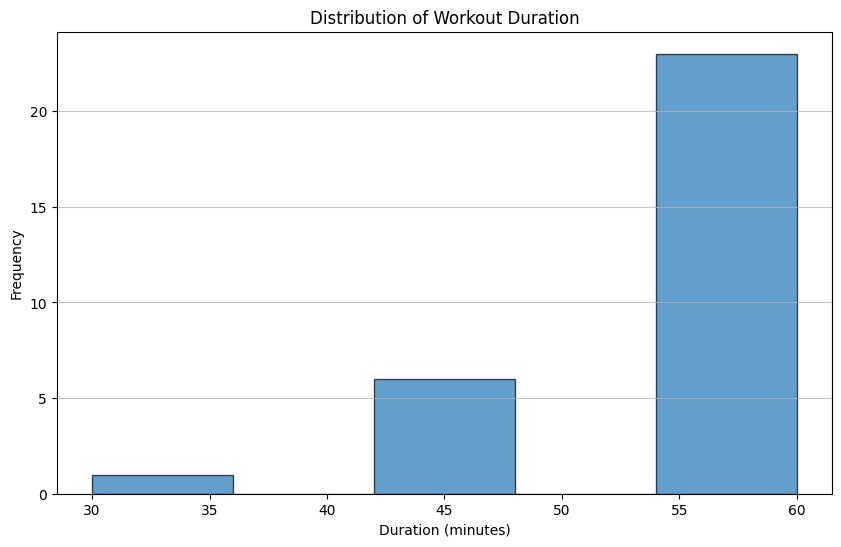

In [210]:
plt.figure(figsize=(10, 6))
plt.hist(df['Duration'], bins=5, alpha=0.7, edgecolor='black')
plt.title('Distribution of Workout Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [211]:
# plt.figure(figsize=(6,4))
# sns.boxplot(y=df["Duration"])
# plt.title("Box Plot of Workout Duration")
# plt.show()

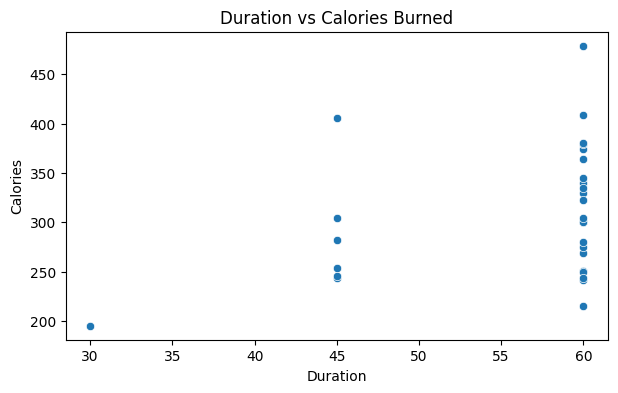

In [212]:
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=df,
    x="Duration",
    y="Calories"
)

plt.title("Duration vs Calories Burned")
plt.show()

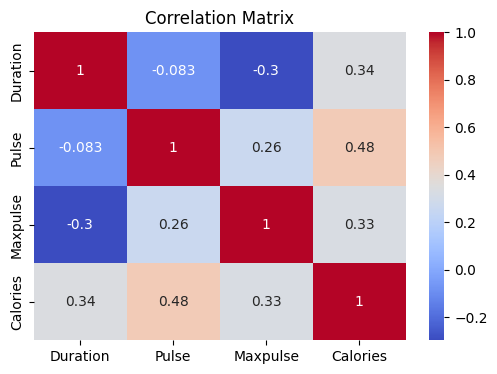

In [213]:
plt.figure(figsize=(6,4))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

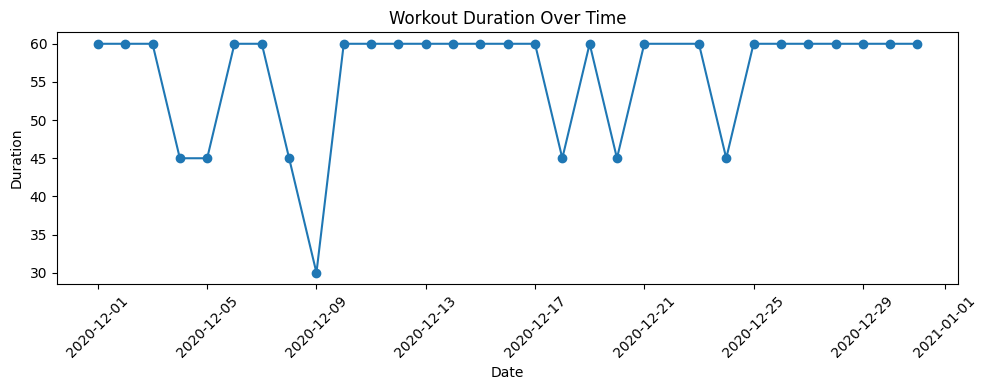

In [214]:
plt.figure(figsize=(10,4))

plt.plot(
    df["Date"],
    df["Duration"],
    marker="o"
)

plt.title("Workout Duration Over Time")
plt.xlabel("Date")
plt.ylabel("Duration")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()